# Анализ оценки ER-модели на trusted-разметке реальных данных

Визуализация результатов `15_test_on_real_labels.py` — оценка модели на:
- **gold** — 398 пар, размечены ВРУЧНУЮ (см. `12_verify_labels.ipynb`)
- **silver** — high-conf LLM-метки минус ненадёжная зона no-match с высоким cosine sim
- **silver_plus_gold** — объединение (gold перетирает LLM)

Сравнивается GNN модель vs raw rubert-tiny2 baseline по F1 / Precision / Recall / ROC-AUC / AP.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.figsize'] = (12, 4.5)

OUTPUT_DIR = Path('../output')

# Все модели, для которых ищем JSON-результаты (имя → путь к чекпоинту).
# Если хочешь сравнить только часть — отредактируй словарь.
MODELS = {
    'v3 GAT (NT-Xent)': OUTPUT_DIR / 'v3_gat_model_real_trusted_eval.json',
    'v3 GAT (BCE)':     OUTPUT_DIR / 'v3_gat_bce_model_real_trusted_eval.json',
    'v14 MRL (NT-Xent)': OUTPUT_DIR / 'v14_mrl_gat_model_real_trusted_eval.json',
    'v14 MRL (BCE)':     OUTPUT_DIR / 'v14_mrl_gat_bce_model_real_trusted_eval.json',
}

results = {}
for name, path in MODELS.items():
    if path.exists():
        with open(path) as f:
            results[name] = json.load(f)
        print(f'OK  {name:25s}  {path.name}')
    else:
        print(f'-   {name:25s}  (нет {path.name})')

assert results, 'Ни одного JSON-результата не найдено. Запусти experiments/15_test_on_real_labels.py'

OK  v3 GAT (NT-Xent)           v3_gat_model_real_trusted_eval.json
OK  v3 GAT (BCE)               v3_gat_bce_model_real_trusted_eval.json
OK  v14 MRL (NT-Xent)          v14_mrl_gat_model_real_trusted_eval.json
OK  v14 MRL (BCE)              v14_mrl_gat_bce_model_real_trusted_eval.json


## 1. Сводная таблица: GNN vs Baseline по тирам

In [2]:
def to_long_df(results: dict) -> pd.DataFrame:
    rows = []
    for model, model_res in results.items():
        for tier, tier_res in model_res.items():
            for method in ('GNN', 'Baseline'):
                m = tier_res.get(method, {})
                if not m or 'f1' not in m:
                    continue
                rows.append({
                    'model': model, 'tier': tier, 'method': method,
                    'n_pairs': m.get('n_pairs'),
                    'n_pos': m.get('n_pos'),
                    'threshold': m.get('threshold'),
                    'f1': m.get('f1'),
                    'precision': m.get('precision'),
                    'recall': m.get('recall'),
                    'roc_auc': m.get('roc_auc'),
                    'avg_precision': m.get('avg_precision'),
                })
    return pd.DataFrame(rows)

df = to_long_df(results)
with pd.option_context('display.float_format', '{:0.3f}'.format):
    display(df.sort_values(['tier', 'model', 'method']).reset_index(drop=True))

,model,tier,method,n_pairs,n_pos,threshold,f1,precision,recall,roc_auc,avg_precision
0,v14 MRL (BCE),gold,Baseline,398,208,0.781,0.692,0.531,0.995,0.465,0.523
1,v14 MRL (BCE),gold,GNN,398,208,-0.284,0.686,0.523,1.000,0.512,0.536
2,v14 MRL (NT-Xent),gold,Baseline,398,208,0.781,0.692,0.531,0.995,0.465,0.523
3,v14 MRL (NT-Xent),gold,GNN,398,208,-0.232,0.688,0.524,1.000,0.606,0.610
4,v3 GAT (BCE),gold,Baseline,398,208,0.781,0.692,0.531,0.995,0.465,0.523
5,v3 GAT (BCE),gold,GNN,398,208,-0.067,0.688,0.528,0.986,0.524,0.537
6,v3 GAT (NT-Xent),gold,Baseline,398,208,0.781,0.692,0.531,0.995,0.465,0.523
7,v3 GAT (NT-Xent),gold,GNN,398,208,0.196,0.706,0.569,0.928,0.615,0.612
8,v14 MRL (BCE),silver,Baseline,18236,2139,0.744,0.210,0.117,0.999,0.488,0.116
9,v14 MRL (BCE),silver,GNN,18236,2139,0.375,0.279,0.209,0.419,0.646,0.226


## 2. Бар-графики: F1 / ROC-AUC / Average Precision

Для каждого тира — сравнение моделей и baseline.

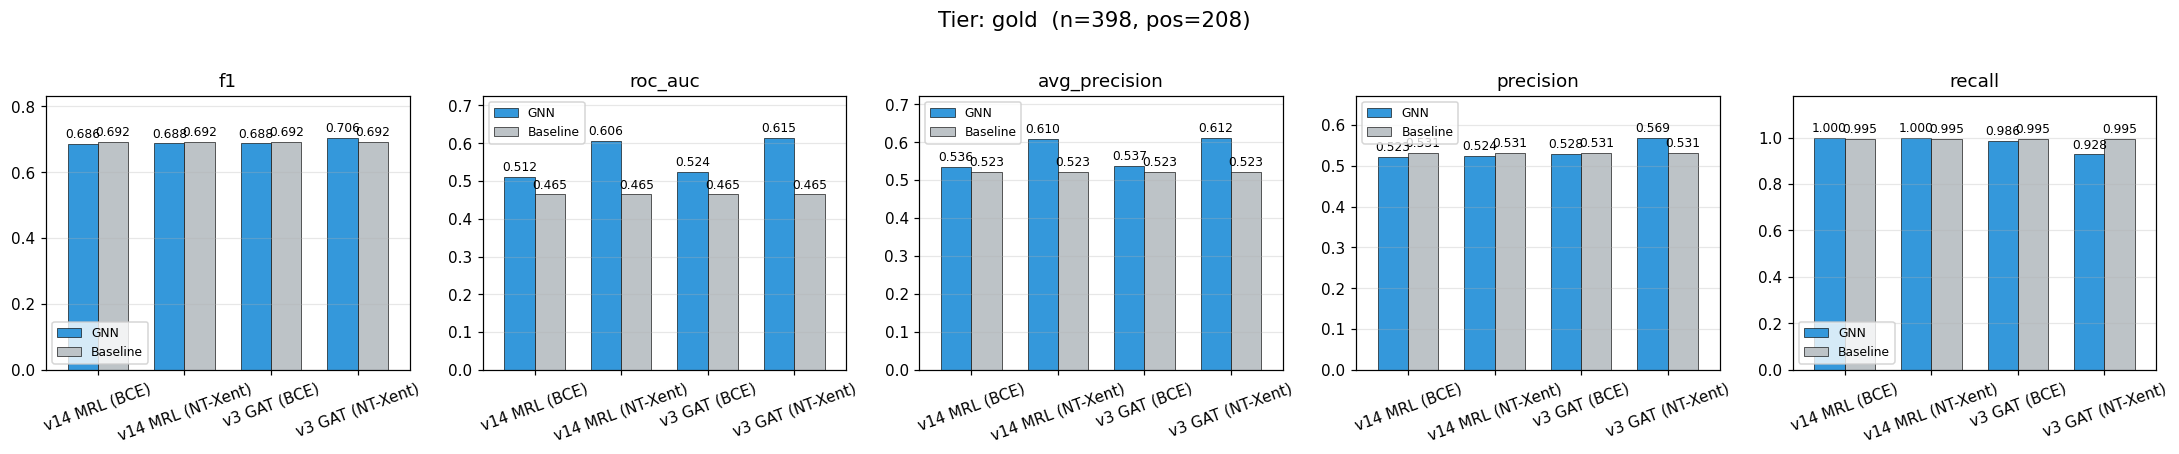

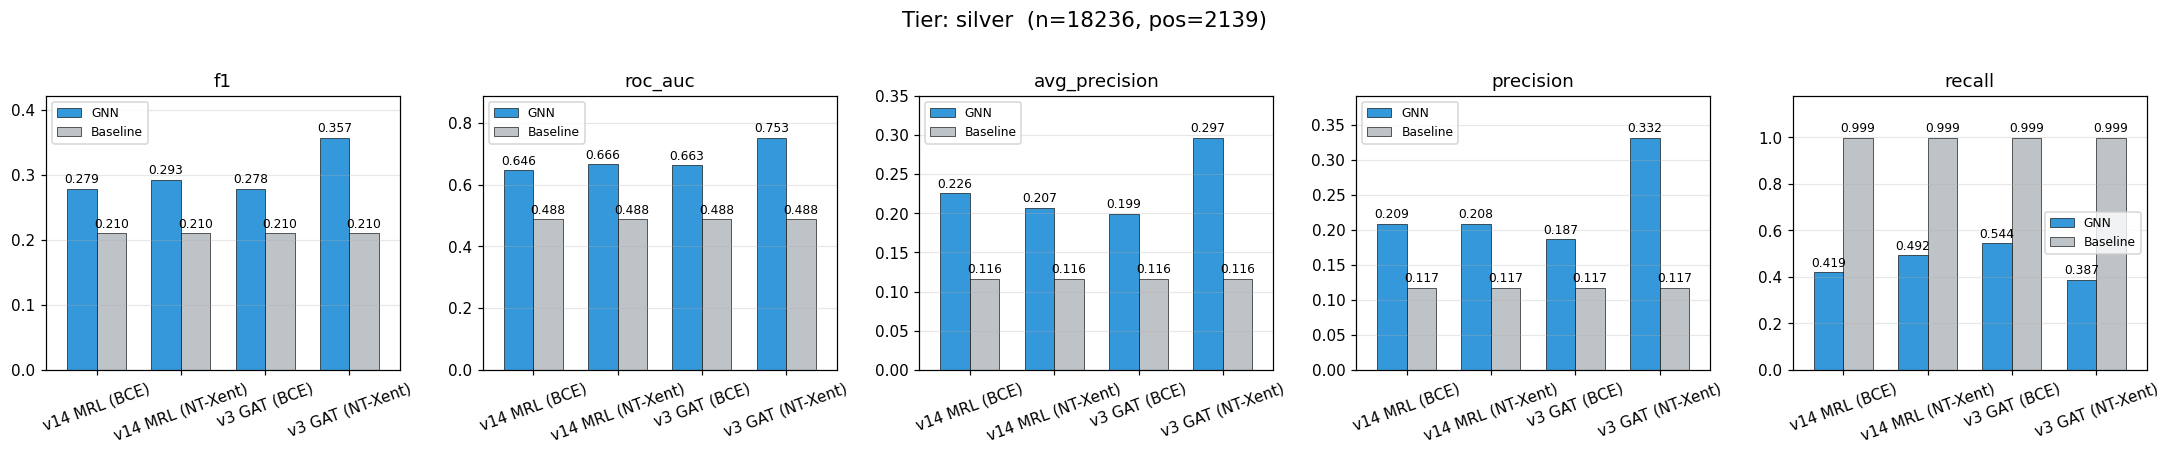

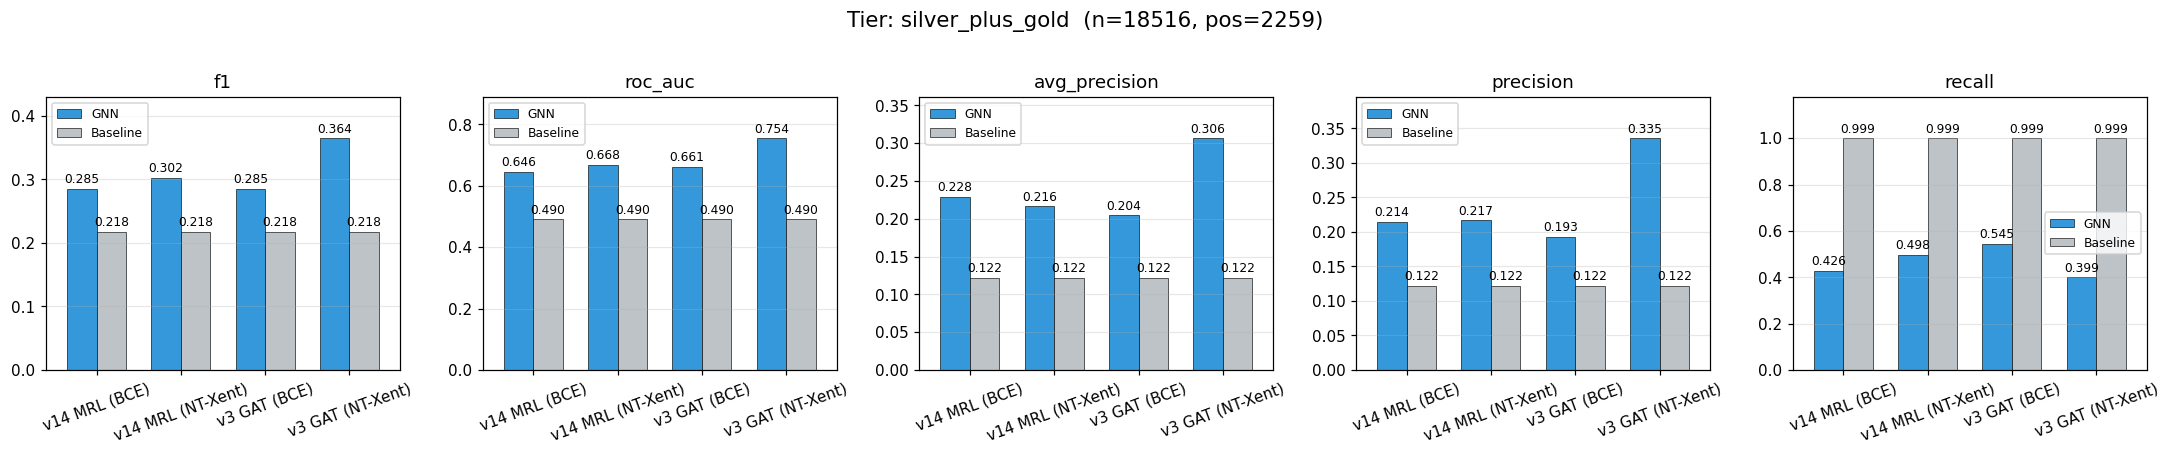

In [3]:
metrics_to_plot = ['f1', 'roc_auc', 'avg_precision', 'precision', 'recall']
tiers = sorted(df['tier'].unique())

for tier in tiers:
    sub = df[df['tier'] == tier]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 4),
                              sharey=False)
    n_pairs = int(sub['n_pairs'].iloc[0])
    n_pos = int(sub['n_pos'].iloc[0])
    fig.suptitle(f'Tier: {tier}  (n={n_pairs}, pos={n_pos})', fontsize=14, y=1.02)

    for ax, metric in zip(axes, metrics_to_plot):
        pivot = sub.pivot(index='model', columns='method', values=metric)
        pivot = pivot[[c for c in ('GNN', 'Baseline') if c in pivot.columns]]
        colors = {'GNN': '#3498db', 'Baseline': '#bdc3c7'}
        pivot.plot.bar(ax=ax, color=[colors[c] for c in pivot.columns],
                       edgecolor='black', linewidth=0.4, width=0.7)
        for cont in ax.containers:
            ax.bar_label(cont, fmt='%.3f', fontsize=8, padding=2)
        ax.set_title(metric)
        ax.set_xlabel('')
        ax.set_ylim(0, max(0.05, pivot.values.max() * 1.18 if pivot.size else 1))
        ax.tick_params(axis='x', rotation=20)
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 3. GNN uplift над baseline

Δ = метрика(GNN) − метрика(Baseline). Положительные значения = модель лучше raw rubert.

d_f1  d_precision  d_recall  d_roc_auc  \
tier             model                                                        
gold             v3 GAT (NT-Xent)  +0.013       +0.039    -0.067     +0.150   
                 v3 GAT (BCE)      -0.004       -0.002    -0.010     +0.060   
                 v14 MRL (NT-Xent) -0.005       -0.007    +0.005     +0.141   
                 v14 MRL (BCE)     -0.006       -0.008    +0.005     +0.047   
silver           v3 GAT (NT-Xent)  +0.147       +0.215    -0.612     +0.265   
                 v3 GAT (BCE)      +0.068       +0.069    -0.455     +0.175   
                 v14 MRL (NT-Xent) +0.083       +0.091    -0.507     +0.178   
                 v14 MRL (BCE)     +0.069       +0.091    -0.580     +0.159   
silver_plus_gold v3 GAT (NT-Xent)  +0.147       +0.213    -0.600     +0.264   
                 v3 GAT (BCE)      +0.067       +0.071    -0.454     +0.171   
                 v14 MRL (NT-Xent) +0.084       +0.095    -0.501     +0.178   
                 v14 MRL (BCE)     +0.067       +0.092    -0.573     +0.156   

                                     d_ap  
tier             model                     
gold             v3 GAT (NT-Xent)  +0.090  
                 v3 GAT (BCE)      +0.014  
                 v14 MRL (NT-Xent) +0.087  
                 v14 MRL (BCE)     +0.013  
silver           v3 GAT (NT-Xent)  +0.181  
                 v3 GAT (BCE)      +0.083  
                 v14 MRL (NT-Xent) +0.091  
                 v14 MRL (BCE)     +0.110  
silver_plus_gold v3 GAT (NT-Xent)  +0.184  
                 v3 GAT (BCE)      +0.082  
                 v14 MRL (NT-Xent) +0.094  
                 v14 MRL (BCE)     +0.106

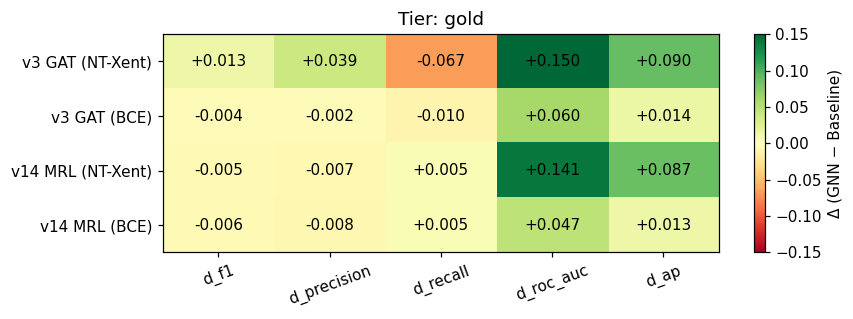

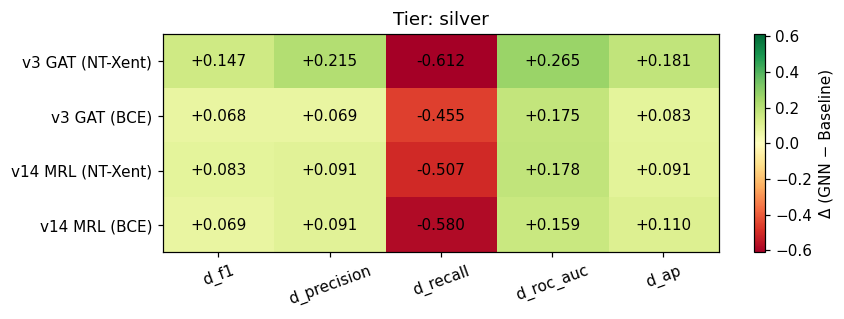

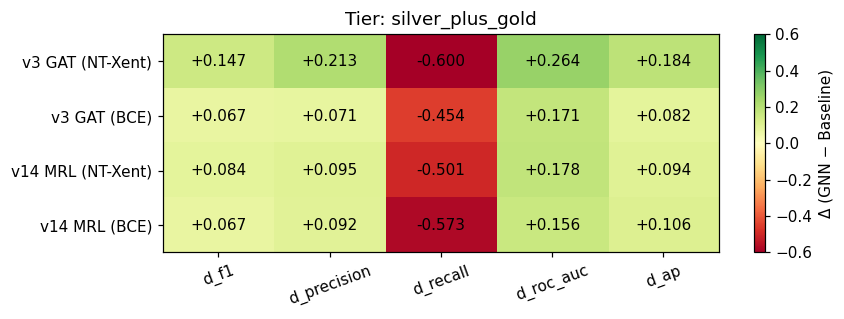

In [4]:
uplift_rows = []
for tier in tiers:
    for model in df['model'].unique():
        gnn = df[(df['tier']==tier) & (df['model']==model) & (df['method']=='GNN')]
        base = df[(df['tier']==tier) & (df['model']==model) & (df['method']=='Baseline')]
        if gnn.empty or base.empty:
            continue
        g, b = gnn.iloc[0], base.iloc[0]
        uplift_rows.append({
            'tier': tier, 'model': model,
            'd_f1': g['f1'] - b['f1'],
            'd_precision': g['precision'] - b['precision'],
            'd_recall': g['recall'] - b['recall'],
            'd_roc_auc': g['roc_auc'] - b['roc_auc'],
            'd_ap': g['avg_precision'] - b['avg_precision'],
        })

uplift_df = pd.DataFrame(uplift_rows)
with pd.option_context('display.float_format', '{:+0.3f}'.format):
    display(uplift_df.set_index(['tier', 'model']))

# Heatmap по моделям × метрикам, для каждого тира
for tier in tiers:
    sub = uplift_df[uplift_df['tier'] == tier].set_index('model').drop(columns='tier')
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 1 + 0.5 * len(sub)))
    vmax = max(0.001, np.abs(sub.values).max())
    im = ax.imshow(sub.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, rotation=20)
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index)
    for i in range(len(sub.index)):
        for j in range(len(sub.columns)):
            ax.text(j, i, f'{sub.values[i, j]:+.3f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label='Δ (GNN − Baseline)')
    ax.set_title(f'Tier: {tier}')
    plt.tight_layout()
    plt.show()

## 4. Per-strategy breakdown (gold)

Для тира `gold` показываем как модель отрабатывает на каждой стратегии выборки из `12_verify_labels.ipynb`. Это позволяет увидеть, где GNN реально помогает (например, спасает ли false-no-match по высокому sim) и где сыпется (low-sim матчи).

,model,method,strategy,n,n_pos,f1,precision,recall
0,v14 MRL (BCE),Baseline,match_high_random,50,43,0.925,0.860,1.000
1,v14 MRL (BCE),GNN,match_high_random,50,43,0.925,0.860,1.000
2,v14 MRL (NT-Xent),Baseline,match_high_random,50,43,0.925,0.860,1.000
3,v14 MRL (NT-Xent),GNN,match_high_random,50,43,0.925,0.860,1.000
4,v3 GAT (BCE),Baseline,match_high_random,50,43,0.925,0.860,1.000
5,v3 GAT (BCE),GNN,match_high_random,50,43,0.923,0.875,0.977
6,v3 GAT (NT-Xent),Baseline,match_high_random,50,43,0.925,0.860,1.000
7,v3 GAT (NT-Xent),GNN,match_high_random,50,43,0.897,0.886,0.907
8,v14 MRL (BCE),Baseline,match_low_sim,48,37,0.892,0.804,1.000
9,v14 MRL (BCE),GNN,match_low_sim,48,37,0.871,0.771,1.000


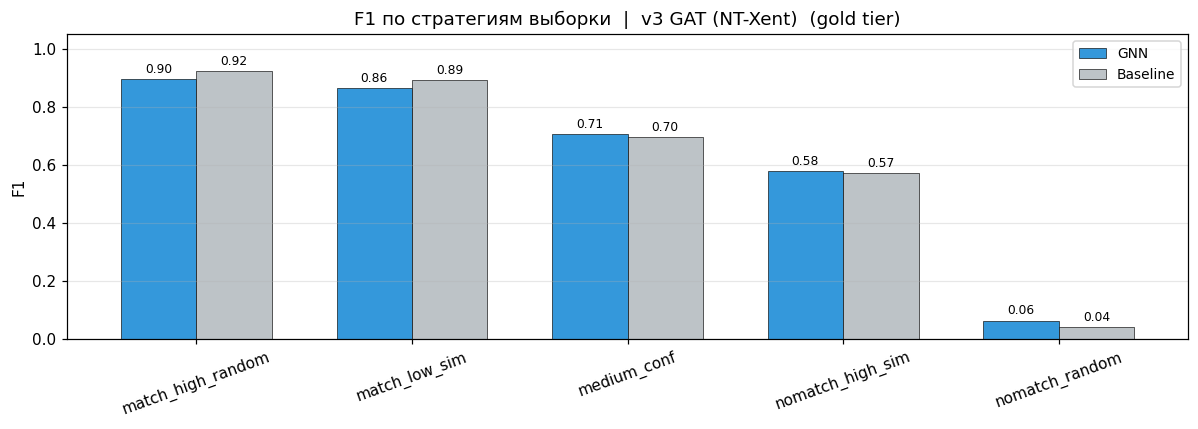

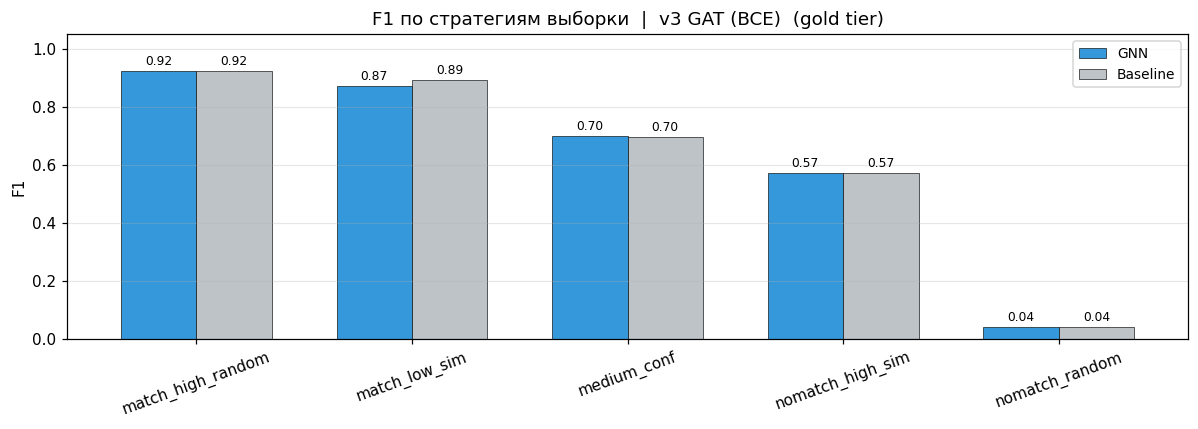

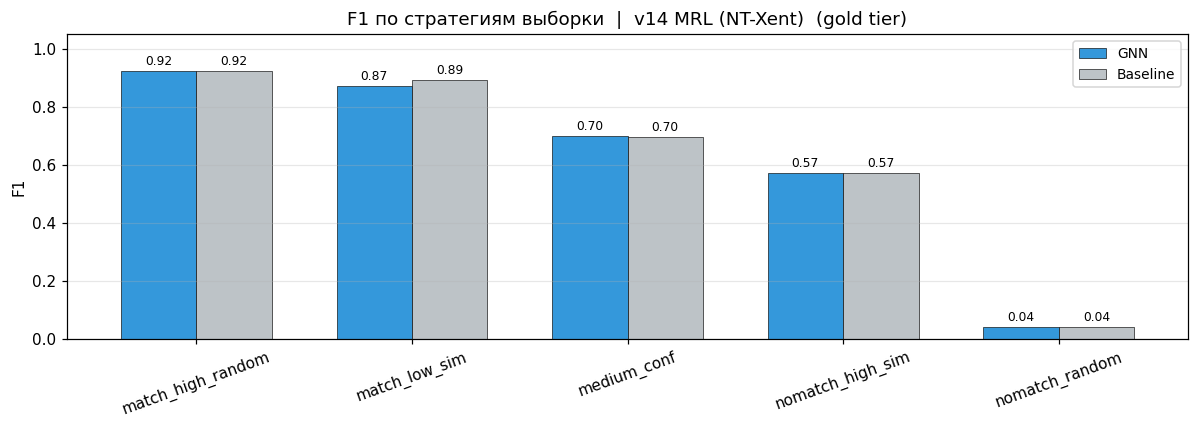

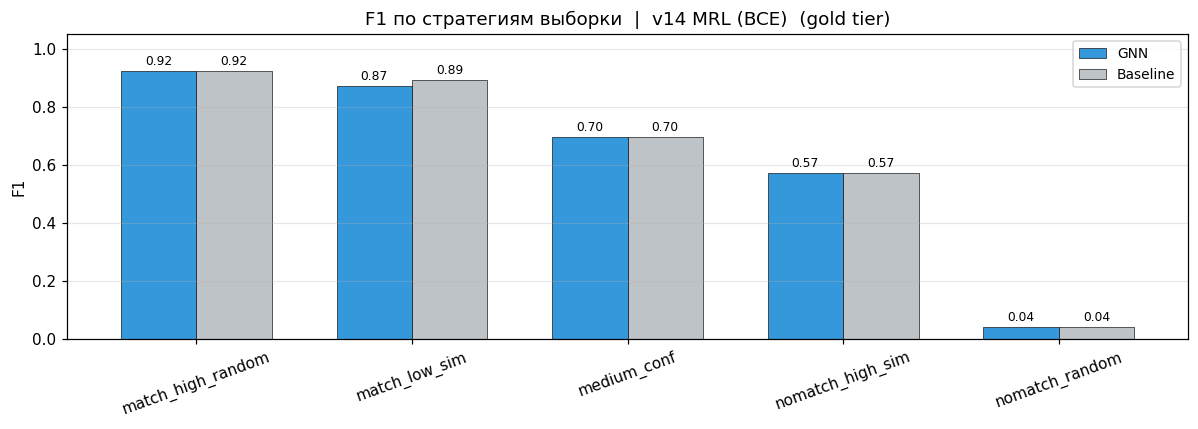

In [5]:
rows = []
for model, model_res in results.items():
    gold = model_res.get('gold', {})
    for method in ('GNN', 'Baseline'):
        per_strat = gold.get(method, {}).get('per_strategy', {})
        for strat, m in per_strat.items():
            if 'f1' not in m:
                continue
            rows.append({
                'model': model, 'method': method, 'strategy': strat,
                'n': m['n'], 'n_pos': m['n_pos'],
                'f1': m['f1'], 'precision': m['precision'], 'recall': m['recall'],
            })

if not rows:
    print('Нет per_strategy данных (может, gold не загружен или strategy=NA)')
else:
    strat_df = pd.DataFrame(rows)
    with pd.option_context('display.float_format', '{:0.3f}'.format):
        display(strat_df.sort_values(['strategy', 'model', 'method']).reset_index(drop=True))

    # Бар-чарт F1 по стратегиям
    strategies = sorted(strat_df['strategy'].unique())
    for model in strat_df['model'].unique():
        sub = strat_df[strat_df['model'] == model]
        if sub.empty:
            continue
        pivot = sub.pivot(index='strategy', columns='method', values='f1').reindex(strategies)
        pivot = pivot[[c for c in ('GNN', 'Baseline') if c in pivot.columns]]
        fig, ax = plt.subplots(figsize=(11, 4))
        pivot.plot.bar(ax=ax, color=[{'GNN':'#3498db', 'Baseline':'#bdc3c7'}[c] for c in pivot.columns],
                       edgecolor='black', linewidth=0.4, width=0.7)
        for cont in ax.containers:
            ax.bar_label(cont, fmt='%.2f', fontsize=8, padding=2)
        ax.set_title(f'F1 по стратегиям выборки  |  {model}  (gold tier)')
        ax.set_ylabel('F1')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=20)
        ax.set_ylim(0, 1.05)
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

## 5. Precision-Recall кривые

Перерасчитываем кривые из самих эмбеддингов — нужны те же файлы, что и в скрипте оценки. Если файлы недоступны, секция пропускается.

**Что для этого нужно** (дополнительно к JSON):
- кэш-граф `output/07_real_data_test/graph.pt` + `id_to_global_*.json`
- чекпоинт модели + опционально `<model>.config.json`
- Excel-файлы для `build_idx_maps`

Так что эта секция работает только когда нотбук запускается на том же сервере, где живут данные.

In [6]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
from sklearn.metrics import precision_recall_curve, roc_curve

try:
    # Импорт из нашего скрипта
    from experiments import __init__ as _  # noqa
except Exception:
    pass

# Подключаемся к функциям из 15_test_on_real_labels через importlib (имя начинается с цифры)
import importlib.util
_spec = importlib.util.spec_from_file_location(
    'exp15', Path('15_test_on_real_labels.py').resolve(),
)
exp15 = importlib.util.module_from_spec(_spec)
try:
    _spec.loader.exec_module(exp15)
    EXP15_AVAILABLE = True
except Exception as e:
    print(f'Не удалось импортировать 15_test_on_real_labels: {e}')
    EXP15_AVAILABLE = False

In [7]:
# Конфигурация: какую модель строить кривые. Меняй под нужный чекпоинт.
MODEL_FOR_CURVES = {
    'path': Path('../output/v3_gat_bce_model.pt'),
    'bce':  True,
    'arch': 'gat',
    'mrl':  False,
    'target_dim': 312,
    'use_input_projection': True,
}

if EXP15_AVAILABLE and MODEL_FOR_CURVES['path'].exists():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 1. trusted-разметка + idx maps
    trusted = exp15.load_trusted_pairs()
    nom_map, spec_map = exp15.build_idx_maps()

    # 2. Граф
    graph = torch.load(exp15.GRAPH_DIR / 'graph.pt', weights_only=False)
    with open(exp15.GRAPH_DIR / 'id_to_global_a.json') as f:
        id_a = json.load(f)
    with open(exp15.GRAPH_DIR / 'id_to_global_b.json') as f:
        id_b = json.load(f)
    if MODEL_FOR_CURVES['mrl']:
        graph.col_embeddings = exp15.mrl_truncate(
            graph.col_embeddings, MODEL_FOR_CURVES['target_dim'],
        )

    # 3. Модель + эмбеддинги
    er_cfg, default_use_proj = exp15.load_er_config(MODEL_FOR_CURVES['path'])
    model = exp15.load_model(
        graph, MODEL_FOR_CURVES['path'],
        bce=MODEL_FOR_CURVES['bce'], arch=MODEL_FOR_CURVES['arch'],
        use_input_projection=MODEL_FOR_CURVES['use_input_projection'] and default_use_proj,
        er_config=er_cfg, device=device,
    )
    from table_unifier.training.er_trainer import get_row_embeddings
    gnn_emb = get_row_embeddings(model, graph, device=device).cpu()
    base_emb = F.normalize(graph['row'].x.float().cpu(), p=2, dim=-1)

    # 4. PR/ROC по тирам
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    color_map = {'gold': '#27ae60', 'silver': '#3498db', 'silver_plus_gold': '#9b59b6'}
    for tier_name, tier_df in trusted.items():
        pairs, mask = exp15.pairs_to_tensor(tier_df, nom_map, spec_map, id_a, id_b)
        if pairs.shape[0] == 0:
            continue
        labels = pairs[:, 2].numpy()
        if len(np.unique(labels)) < 2:
            continue
        for emb, label_suffix, ls in [(gnn_emb, 'GNN', '-'), (base_emb, 'Base', '--')]:
            scores = (emb[pairs[:, 0]] * emb[pairs[:, 1]]).sum(dim=1).numpy()
            p, r, _ = precision_recall_curve(labels, scores)
            fpr, tpr, _ = roc_curve(labels, scores)
            axes[0].plot(r, p, ls, color=color_map.get(tier_name, 'gray'),
                         label=f'{tier_name} / {label_suffix}', alpha=0.85)
            axes[1].plot(fpr, tpr, ls, color=color_map.get(tier_name, 'gray'),
                         label=f'{tier_name} / {label_suffix}', alpha=0.85)
    axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
    axes[0].set_title('Precision-Recall'); axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)
    axes[1].plot([0, 1], [0, 1], ':', color='gray', alpha=0.5)
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC'); axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)
    plt.suptitle(f'Кривые для модели: {MODEL_FOR_CURVES["path"].name}', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Секция пропущена: не доступен либо 15_test_on_real_labels.py, либо чекпоинт модели.')

FileNotFoundError: [Errno 2] No such file or directory: 'data/labeled/labeled_pairs.parquet'

## 6. Итоги

Что искать в результатах:

- **GNN > Baseline по AUC на gold-тире** — модель действительно учится сопоставлять реальные данные, а не повторяет rubert-cosine.
- **F1@best_θ заметно выше у GNN** — модель не просто переупорядочивает, а реально различает классы при разумном пороге.
- **Per-strategy:** интересен прирост на `nomatch_high_sim` (60% reliability в LLM) и `match_low_sim` (77%) — это самые тяжёлые случаи. Если GNN там вытягивает, значит, она научилась смотреть на структуру (кодов, артикулов), а не только на семантическое сходство, на котором rubert проваливается.
- **Silver vs gold:** silver больше по объёму, но содержит шум LLM. Если метрики на silver сильно лучше, чем на gold — модель ловит закономерности LLM-разметки, а не реальные match'и.